# elevator-rmnd-lstm

Use the simulated dataset generated by `dataset.py` to train
regression models, in order to predict the remaining useful life (RUL)
of lifts.

**This approach uses an LSTM.**

In [1]:
import gc

gc.collect()

14

In [2]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

!pip install wandb weave pytorch_lightning torchmetrics
!wandb login --relogin

sns.set_theme(context="notebook", style="ticks")

INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 

## preprocessing
* Import the simulated dataset
* ~~Convert lift ids to integers~~ [already handled by `dataset.py`]
* ~~Compute instantaneous time derivatives of each sensor metric~~ [already handled by `dataset.py`]
* ~~Compute RUL in h~~ [already handled by `dataset.py`]
* Split data into training/testing sets
* Scale data with a `Scaler`

In [3]:
from google.colab import files
uploaded = files.upload()

FNAME = "liftdata_v4.csv"
df_full = pd.read_csv(FNAME)
df_full.head(10)

Saving liftdata_v4.csv to liftdata_v4.csv


,TIMESTAMP,LIFT_ID,LIFT_MODEL,MODEL_ID,LIFT_AGE_HR,AGE_SINCE_LAST_MNT,ARM_DIST_mm,ARM_DIST_DELTA,DOOR_DIST_mm,DOOR_DIST_DELTA,...,FLOOR_DOOR_RATIO,ROPE_MFL_mV,ROPE_MFL_DELTA,ROPE_MFL_CUM,BEARING_TEMP_C,BEARING_TEMP_DELTA,BEARING_TEMP_CUM,TEMP_X_ROPE,RUL_HR,MAINTENANCE_DONE
0,2024-01-01 00:00:00,LIFT_001,Otis Gen2,1,13.2,NaN,0.478,0.000,2.013,0.000,...,0.113760,10.292,0.000,10.292,33.590,0.000,33.590,345.708280,2160.0,0
1,2024-01-01 12:00:00,LIFT_001,Otis Gen2,1,25.2,NaN,0.539,0.061,1.943,-0.070,...,0.000000,10.361,0.069,20.653,30.604,-2.986,64.194,317.088044,2159.0,0
2,2024-01-02 00:00:00,LIFT_001,Otis Gen2,1,37.2,NaN,0.509,-0.030,1.983,0.040,...,0.016641,8.958,-1.403,29.611,32.360,1.756,96.554,289.880880,2158.0,0
3,2024-01-02 12:00:00,LIFT_001,Otis Gen2,1,49.2,NaN,0.527,0.018,1.878,-0.105,...,0.068158,9.502,0.544,39.113,34.949,2.589,131.503,332.085398,2157.0,0
4,2024-01-03 00:00:00,LIFT_001,Otis Gen2,1,61.2,NaN,0.488,-0.039,2.109,0.231,...,0.000000,9.736,0.234,48.849,31.700,-3.249,163.203,308.631200,2156.0,0
5,2024-01-03 12:00:00,LIFT_001,Otis Gen2,1,73.2,NaN,0.461,-0.027,1.958,-0.151,...,0.000000,9.753,0.017,58.602,34.621,2.921,197.824,337.658613,2155.0,0
6,2024-01-04 00:00:00,LIFT_001,Otis Gen2,1,85.2,NaN,0.493,0.032,2.016,0.058,...,0.000000,10.051,0.298,68.653,31.269,-3.352,229.093,314.284719,2154.0,0
7,2024-01-04 12:00:00,LIFT_001,Otis Gen2,1,97.2,NaN,0.505,0.012,1.914,-0.102,...,0.073668,9.453,-0.598,78.106,33.097,1.828,262.190,312.865941,2153.0,0
8,2024-01-05 00:00:00,LIFT_001,Otis Gen2,1,109.2,NaN,0.481,-0.024,1.997,0.083,...,0.046570,9.809,0.356,87.915,32.230,-0.867,294.420,316.144070,2152.0,0
9,2024-01-05 12:00:00,LIFT_001,Otis Gen2,1,121.2,NaN,0.465,-0.016,2.129,0.132,...,0.218882,10.396,0.587,98.311,32.570,0.340,326.990,338.597720,2151.0,0


In [4]:
# Remove NaN values
df_full.dropna(inplace=True)

Since there exist rows that have `np.inf` as their predicted RUL, extract those rows for experimentation later on.
Retain the remaining roles (with valid RULs) for training and testing.

In [5]:
df_experimental = df_full[df_full["RUL_HR"] == np.inf]
df_useful = df_full[df_full["RUL_HR"] != np.inf]

assert not df_experimental.isna().any().any()
assert not df_useful.isna().any().any()

df_useful.head(40)

,TIMESTAMP,LIFT_ID,LIFT_MODEL,MODEL_ID,LIFT_AGE_HR,AGE_SINCE_LAST_MNT,ARM_DIST_mm,ARM_DIST_DELTA,DOOR_DIST_mm,DOOR_DIST_DELTA,...,FLOOR_DOOR_RATIO,ROPE_MFL_mV,ROPE_MFL_DELTA,ROPE_MFL_CUM,BEARING_TEMP_C,BEARING_TEMP_DELTA,BEARING_TEMP_CUM,TEMP_X_ROPE,RUL_HR,MAINTENANCE_DONE
2160,2026-12-16 00:00:00,LIFT_001,Otis Gen2,1,25933.2,0.000000,0.530,-0.017,2.742,0.064,...,0.278264,11.818,-0.646,24083.831,47.738,-0.448,90211.616,564.167684,0.0,1
2161,2026-12-16 12:00:00,LIFT_001,Otis Gen2,1,25945.2,0.000000,0.547,0.017,2.522,-0.220,...,0.394925,11.236,-0.582,24095.067,47.772,0.034,90259.388,536.766192,2159.0,0
2162,2026-12-17 00:00:00,LIFT_001,Otis Gen2,1,25957.2,0.002268,0.522,-0.025,2.527,0.005,...,0.352592,11.715,0.479,24106.782,49.652,1.880,90309.040,581.673180,2158.0,0
2163,2026-12-17 12:00:00,LIFT_001,Otis Gen2,1,25969.2,0.002268,0.566,0.044,2.584,0.057,...,0.330108,10.480,-1.235,24117.262,48.725,-0.927,90357.765,510.638000,2157.0,0
2164,2026-12-18 00:00:00,LIFT_001,Otis Gen2,1,25981.2,0.004535,0.519,-0.047,2.485,-0.099,...,0.224547,11.297,0.817,24128.559,48.566,-0.159,90406.331,548.650102,2156.0,0
2165,2026-12-18 12:00:00,LIFT_001,Otis Gen2,1,25993.2,0.004535,0.528,0.009,2.446,-0.039,...,0.212592,12.082,0.785,24140.641,47.462,-1.104,90453.793,573.435884,2155.0,0
2166,2026-12-19 00:00:00,LIFT_001,Otis Gen2,1,26005.2,0.004535,0.576,0.048,2.630,0.184,...,0.319772,11.947,-0.135,24152.588,48.063,0.601,90501.856,574.208661,2154.0,0
2167,2026-12-19 12:00:00,LIFT_001,Otis Gen2,1,26017.2,0.006803,0.534,-0.042,2.513,-0.117,...,0.249900,12.173,0.226,24164.761,50.318,2.255,90552.174,612.521014,2153.0,0
2168,2026-12-20 00:00:00,LIFT_001,Otis Gen2,1,26029.2,0.006803,0.486,-0.048,2.462,-0.051,...,0.365556,11.414,-0.759,24176.175,49.286,-1.032,90601.460,562.550404,2152.0,0
2169,2026-12-20 12:00:00,LIFT_001,Otis Gen2,1,26041.2,0.009070,0.566,0.080,2.519,0.057,...,0.296149,11.438,0.024,24187.613,48.935,-0.351,90650.395,559.718530,2151.0,0


In [6]:
X_cols = ['MODEL_ID', 'LIFT_AGE_HR', 'AGE_SINCE_LAST_MNT', 'ARM_DIST_mm', 'ARM_DIST_DELTA', 'DOOR_DIST_mm', 'DOOR_DIST_DELTA', 'FLOOR_DIST_mm', 'FLOOR_DIST_DELTA', 'FLOOR_DOOR_RATIO', 'ROPE_MFL_mV', 'ROPE_MFL_DELTA', 'ROPE_MFL_CUM', 'BEARING_TEMP_C', 'BEARING_TEMP_DELTA', 'BEARING_TEMP_CUM', 'TEMP_X_ROPE']

## data preprocessing

a few more preprocessing steps before we get to training:
* create training, validation, and testing splits
* scale the data so that the range isn't large
* then create sequences for an RNN to feed off of

In [7]:
from sklearn.preprocessing import StandardScaler

First create train/val/test splits in the ratio 70/15/15.

We avoid `train_test_split`, since each `lift_id` has a _contiguous_ time series of degradation. Taking random samples may cause misrepresentation. Instead, we simply take a continuous 70% of readings for each lift type to make the training set, and etc.

In [8]:
train_dfs = []
val_dfs = []
test_dfs = []

for lift_id, group in df_useful.groupby('MODEL_ID'):
    # Get the group's data
    group_data = group.reset_index(drop=True)
    n = len(group_data)

    # Calculate split indices for contiguous splits
    train_size = int(n * 0.7)
    val_size = int(n * 0.15)

    # Split contiguously (preserves temporal order)
    train_dfs.append(group_data[:train_size])
    val_dfs.append(group_data[train_size:train_size + val_size])
    test_dfs.append(group_data[train_size + val_size:])

# Concatenate all splits
train_df = pd.concat(train_dfs, ignore_index=True)
val_df = pd.concat(val_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

train_df.head(20)

,TIMESTAMP,LIFT_ID,LIFT_MODEL,MODEL_ID,LIFT_AGE_HR,AGE_SINCE_LAST_MNT,ARM_DIST_mm,ARM_DIST_DELTA,DOOR_DIST_mm,DOOR_DIST_DELTA,...,FLOOR_DOOR_RATIO,ROPE_MFL_mV,ROPE_MFL_DELTA,ROPE_MFL_CUM,BEARING_TEMP_C,BEARING_TEMP_DELTA,BEARING_TEMP_CUM,TEMP_X_ROPE,RUL_HR,MAINTENANCE_DONE
0,2098-11-28 00:00:00,LIFT_003,KONE MonoSpace,0,25932.8,0.000000,0.464,-0.053,2.575,-0.212,...,0.172427,12.951,1.178,24334.353,44.430,-2.171,88213.252,575.412930,0.0,1
1,2098-11-28 12:00:00,LIFT_003,KONE MonoSpace,0,25944.8,0.000000,0.510,0.046,2.565,-0.010,...,0.303314,12.009,-0.942,24346.362,47.613,3.183,88260.865,571.784517,1416.0,0
2,2098-11-29 00:00:00,LIFT_003,KONE MonoSpace,0,25956.8,0.002415,0.501,-0.009,2.727,0.162,...,0.308397,11.588,-0.421,24357.950,46.863,-0.750,88307.728,543.048444,1415.0,0
3,2098-11-29 12:00:00,LIFT_003,KONE MonoSpace,0,25968.8,0.002415,0.523,0.022,2.607,-0.120,...,0.359417,11.831,0.243,24369.781,46.333,-0.530,88354.061,548.165723,1414.0,0
4,2098-11-30 00:00:00,LIFT_003,KONE MonoSpace,0,25980.8,0.004831,0.486,-0.037,2.780,0.173,...,0.146403,11.652,-0.179,24381.433,45.931,-0.402,88399.992,535.188012,1413.0,0
5,2098-11-30 12:00:00,LIFT_003,KONE MonoSpace,0,25992.8,0.004831,0.528,0.042,2.723,-0.057,...,0.296731,12.055,0.403,24393.488,46.454,0.523,88446.446,560.002970,1412.0,0
6,2098-12-01 00:00:00,LIFT_003,KONE MonoSpace,0,26004.8,0.004831,0.531,0.003,2.601,-0.122,...,0.305652,12.782,0.727,24406.270,46.140,-0.314,88492.586,589.761480,1411.0,0
7,2098-12-01 12:00:00,LIFT_003,KONE MonoSpace,0,26016.8,0.007246,0.541,0.010,2.598,-0.003,...,0.373364,12.359,-0.423,24418.629,46.141,0.001,88538.727,570.256619,1410.0,0
8,2098-12-02 00:00:00,LIFT_003,KONE MonoSpace,0,26028.8,0.007246,0.541,0.000,2.754,0.156,...,0.217502,12.350,-0.009,24430.979,45.414,-0.727,88584.141,560.862900,1409.0,0
9,2098-12-02 12:00:00,LIFT_003,KONE MonoSpace,0,26040.8,0.009662,0.495,-0.046,2.581,-0.173,...,0.261526,12.012,-0.338,24442.991,45.896,0.482,88630.037,551.302752,1408.0,0


Then scale the data with `StandardScaler`.

In [9]:
scaler = StandardScaler()
train_df[X_cols] = scaler.fit_transform(train_df[X_cols])
val_df[X_cols] = scaler.transform(val_df[X_cols])
test_df[X_cols] = scaler.transform(test_df[X_cols])

Lastly, create sequences for training with an RNN.

In [10]:
def create_seqs(data, seq_len, feature_cols, target_col="RUL_HR"):
    X, y = [], []

    # Create sequences within each lift separately
    for lift_id, group in data.groupby('LIFT_ID'):
        features = group[feature_cols].values
        targets = group[target_col].values

        for i in range(len(group) - seq_len):
            X.append(features[i : i + seq_len])
            y.append(targets[i + seq_len])
    return np.array(X), np.array(y)


X_train, y_train = create_seqs(train_df, seq_len=50, feature_cols=X_cols)
X_val, y_val = create_seqs(val_df, seq_len=50, feature_cols=X_cols)
X_test, y_test = create_seqs(test_df, seq_len=50, feature_cols=X_cols)

## build an LSTM!
We use `pytorch_lightning` to build an LSTM and then train it on the datasets created.

In [11]:
!pip install torchmetrics pytorch_lightning weave wandb

import os

# The essentials
import torch
import torchmetrics as tm
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset

# For logging
import weave
import wandb

In [12]:
# Some important constants
BATCH_SIZE = 32
N_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
DROPOUT = 0.2

We first create the appropriate datasets and dataloaders, using `TensorDataset` and `DataLoader`.

In [13]:
# create datasets and dataloaders
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32),
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Define an overarching LSTM class, complete with
- training, validation, and testing steps
- model metrics logged
- initialisation of callbacks and trainer objects

In [46]:
class BasicLSTM(pl.LightningModule):
    """A simple LSTM-based regression model for RUL prediction.
    All subsequent models will use this class as a parent."""
    def __init__(
        self,
        input_size: int = X_train.shape[2],
        output_size: int = 1,
        lr: float = LEARNING_RATE,
        weight_decay: float = WEIGHT_DECAY,
        dropout: float = DROPOUT,
    ):
        super(BasicLSTM, self).__init__()
        self.save_hyperparameters()
        torch.set_float32_matmul_precision("high")

        self.lstm1 = nn.LSTM(input_size, 128, num_layers=1, batch_first=True)
        self.dropout_layer = nn.Dropout(p=self.hparams.dropout)
        self.lstm2 = nn.LSTM(128, 64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, output_size)
        self.criterion = nn.MSELoss()

        # assess a few more metrics
        self.mae = tm.MeanAbsoluteError()
        self.r2 = tm.R2Score()
        self.train_mae = self.mae.clone()
        self.val_mae = self.mae.clone()
        self.test_mae = self.mae.clone()
        self.train_r2 = self.r2.clone()
        self.val_r2 = self.r2.clone()
        self.test_r2 = self.r2.clone()

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout_layer(out)
        out, _ = self.lstm2(out)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

    def _shared_step(self, batch):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y.float())
        return loss, y, y_hat

    def training_step(self, batch, batch_idx):
        loss, truths, preds = self._shared_step(batch)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        mae = self.train_mae(preds, truths.float())
        r2 = self.train_r2(preds, truths.float())
        self.log("train_mae", mae, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, truths, preds = self._shared_step(batch)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        mae = self.val_mae(preds, truths.float())
        r2 = self.val_r2(preds, truths.float())
        self.log("val_mae", mae, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, truths, preds = self._shared_step(batch)
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        mae = self.test_mae(preds, truths.float())
        r2 = self.test_r2(preds, truths.float())
        self.log("test_mae", mae, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_r2", r2, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def get_callbacks(self, tnow=None, model_name=None):
        early_stop = pl.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, mode="min", verbose=True,
        )
        checkpoint = pl.callbacks.ModelCheckpoint(
            monitor="val_loss",
            dirpath=f"checkpoints/{model_name}_{tnow}",
            filename="{epoch:02d}-{val_loss:.4f}",
            save_top_k=1,
            mode="min",
            verbose=True,
        )
        lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval="epoch")
        return [early_stop, checkpoint, lr_monitor]

    def get_trainer(self, max_epochs: int, callbacks=None, timestamp=None):
        logger = pl.loggers.WandbLogger(project="zeleo")
        return pl.Trainer(
            max_epochs=max_epochs,
            callbacks=callbacks,
            accelerator="auto",
            devices="auto",
            log_every_n_steps=25,
            logger=logger,
            gradient_clip_val=1.0,
            deterministic=False,
            precision="16-mixed" if torch.cuda.is_available() else "32",
        )

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }

    def gradient_importance(self, dl: DataLoader):
        """
        Evaluates the feature importance, and returns
        a np.ndarray of gradients.
        """
        self.eval()
        all_grads = []

        for x, y in dl:
            x = x.requires_grad_(True)
            y_hat = self(x)
            loss = self.criterion(y_hat, y.float())
            loss.backward()
            grads = x.grad.abs().mean(dim=(0, 1)).numpy()  # (n_features,)
            all_grads.append(grads)

        mean_grads = np.mean(all_grads, axis=0)
        return mean_grads

Then we can embark on **training the model**!

In [15]:
now = datetime.now().strftime("%Y%m%d-%H%M")
model = BasicLSTM()
callbacks = model.get_callbacks(tnow=now, model_name="BasicLSTM")
trainer = model.get_trainer(max_epochs=N_EPOCHS, callbacks=callbacks, timestamp=now)
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: jiyometrik (huomi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: jiyometrik.
weave: View Weave data at https://wandb.ai/huomi/zeleo/weave
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ lstm1         │ LSTM              │ 75.3 K │ train │     0 │
│ 1  │ dropout_layer │ Dropout           │      0 │ train │     0 │
│ 2  │ lstm2         │ LSTM              │ 49.7 K │ train │     0 │
│ 3  │ fc            │ Linear            │     65 │ train │     0 │
│ 4  │ criterion     │ MSELoss           │      0 │ train │     0 │
│ 5  │ mae           │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ r2            │ R2Score           │      0 │ train │     0 │
│ 7  │ train_mae     │ MeanAbsoluteError │      0 │ train │     0 │
│ 8  │ val_mae       │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_mae      │ MeanAbsoluteError │      0 │ train │     0 │
│ 10 │ train_r2      │ R2Score           │      0 │ train │     0 │
│ 11 │ val_r2        │ R2Score           │      0 │ train │     0 │
│ 12 │ test_r2       │ R2Score           │      0 │ train │     0 │
└────┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 124 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 124 K                                                                                                
Total estimated model params size (MB): 0.500                                                                      
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 911289.938
INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 2587: 'val_loss' reached 911289.93750 (best 911289.93750), saving model to '/content/checkpoints/BasicLSTM_20260612-0539/epoch=00-val_loss=911289.9375.ckpt' as top 1
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 219683.375 >= min_delta = 0.0. New best score: 691606.562
INFO:pytorch_lightning.utilities.rank_zero:Epoch 1, global step 5174: 'val_loss' reached 691606.56250 (best 691606.56250), saving model to '/content/checkpoints/BasicLSTM_20260612-0539/epoch=01-val_loss=691606.5625.ckpt' as top 1
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 163438.375 >= min_delta = 0.0. New best score: 528168.188
INFO:pytorch_lightning.utilities.rank_zero:Epoch 2, global step 7761: 'val_loss' reached 528168.18750 (best 528168.18750), saving model to '/content/checkpoints/BasicLSTM_

Finally, test the model.

In [16]:
results = trainer.test(model, test_loader, ckpt_path="best")
test_mae = np.round(results[0]["test_mae"], 4)
test_mae_days = np.round(test_mae / 24, 4)

print(f"*** DONE !!! ***")
print(f"*** test_mae = {test_mae} hours = {test_mae_days} days")
wandb.finish()

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/BasicLSTM_20260612-0539/epoch=08-val_loss=103984.1172.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/BasicLSTM_20260612-0539/epoch=08-val_loss=103984.1172.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │       221951.703125       │
│         test_mae          │        339.8203125        │
│          test_r2          │     -2440.14306640625     │
└───────────────────────────┴───────────────────────────┘

*** DONE !!! ***
*** test_mae = 339.8203 hours = 14.1592 days


epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇█
lr-Adam,█████████████▁
test_loss,▁
test_mae,▁
test_r2,▁
train_loss,█▆▅▄▃▃▂▂▂▁▁▁▁▁
train_mae,█▇▆▆▄▄▃▃▂▂▁▁▁▁
train_r2,▁▃▄▅▆▆▇▇▇█████
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
val_loss,█▆▅▃▃▂▂▁▁▁▁▁▁▁
+2,...


## refine the lstm

Implement another LSTM with a convolutional layer first, as well as an attention mechanism.

In [47]:
class JiyoAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, out):
        weights = torch.softmax(self.attn(out), dim=1)
        ctx = (weights * out).sum(dim=1)
        return ctx, weights


class JiyoLSTM(BasicLSTM):
    """A modified version of the LSTM structure, with convolutional layers and
    an attention mechanism"""

    def __init__(self, ):
        super(JiyoLSTM, self).__init__()
        self.save_hyperparameters()
        self.drop_p = DROPOUT

        # Specify a convolutional layer first
        self.conv = nn.Conv1d(
            in_channels=X_train.shape[2],
            out_channels=32,
            kernel_size=5,
            padding=5//2,
        )
        self.conv_drop = nn.Dropout(p=self.drop_p)

        # Then the remaining LSTM layers
        self.lstm = nn.LSTM(32, 128, num_layers=2, batch_first=True, dropout=self.drop_p)
        self.attention = JiyoAttention(128)

        # and finally the classifier
        self.fc1 = nn.Linear(128, 32)
        self.fc2 = nn.Linear(32, 1)
        self.fc_drop = nn.Dropout(p=self.drop_p)
        self.criterion = nn.MSELoss()


    def forward(self, x):
        # CNN expects multi-dim input
        out = x.permute(0, 2, 1)
        out = self.conv(out)
        out = torch.relu(out)
        out = self.dropout_layer(out)
        out = out.permute(0, 2, 1)

        # LSTM + Attn
        out, _ = self.lstm(out)
        out, attention_weights = self.attention(out)

        # classifier
        out = torch.relu(self.fc1(out))
        out = self.fc2(self.fc_drop(out))

        return out.squeeze(-1)

In [48]:
jiyomodel = JiyoLSTM().to("cuda:0")
jiyonow = datetime.now().strftime("%Y%m%d-%H%M")
callbacks = jiyomodel.get_callbacks(tnow=jiyonow, model_name="JiyoLSTM")
jiyotrainer = jiyomodel.get_trainer(max_epochs=N_EPOCHS, callbacks=callbacks, timestamp=jiyonow)
jiyotrainer.fit(jiyomodel, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: jiyometrik.
weave: View Weave data at https://wandb.ai/huomi/zeleo/weave
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ lstm1         │ LSTM              │ 75.3 K │ train │     0 │
│ 1  │ dropout_layer │ Dropout           │      0 │ train │     0 │
│ 2  │ lstm2         │ LSTM              │ 49.7 K │ train │     0 │
│ 3  │ fc            │ Linear            │     65 │ train │     0 │
│ 4  │ criterion     │ MSELoss           │      0 │ train │     0 │
│ 5  │ mae           │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ r2            │ R2Score           │      0 │ train │     0 │
│ 7  │ train_mae     │ MeanAbsoluteError │      0 │ train │     0 │
│ 8  │ val_mae       │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_mae      │ MeanAbsoluteError │      0 │ train │     0 │
│ 10 │ train_r2      │ R2Score           │      0 │ train │     0 │
│ 11 │ val_r2        │ R2Score           │      0 │ train │     0 │
│ 12 │ test_r2       │ R2Score           │      0 │ train │     0 │
│ 13 │ conv          │ Conv1d            │  2.8 K │ train │     0 │
│ 14 │ conv_drop     │ Dropout           │      0 │ train │     0 │
│ 15 │ lstm          │ LSTM              │  215 K │ train │     0 │
│ 16 │ attention     │ JiyoAttention     │    129 │ train │     0 │
│ 17 │ fc1           │ Linear            │  4.1 K │ train │     0 │
│ 18 │ fc2           │ Linear            │     33 │ train │     0 │
│ 19 │ fc_drop       │ Dropout           │      0 │ train │     0 │
└────┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 347 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 347 K                                                                                                
Total estimated model params size (MB): 1.388                                                                      
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 116898.227
INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 2587: 'val_loss' reached 116898.22656 (best 116898.22656), saving model to '/content/checkpoints/JiyoLSTM_20260612-0631/epoch=00-val_loss=116898.2266.ckpt' as top 1
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 10440.516 >= min_delta = 0.0. New best score: 106457.711
INFO:pytorch_lightning.utilities.rank_zero:Epoch 1, global step 5174: 'val_loss' reached 106457.71094 (best 106457.71094), saving model to '/content/checkpoints/JiyoLSTM_20260612-0631/epoch=01-val_loss=106457.7109.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 2, global step 7761: 'val_loss' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 3, global step 10348: 'val_loss' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:Epoch 4, global step 12935: 'val_loss' was not in top 1
INFO:pytorch

In [49]:
jiyoresults = jiyotrainer.test(jiyomodel, test_loader, ckpt_path="best")
jiyotest_mae = np.round(jiyoresults[0]["test_mae"], 4)
jiyotest_mae_days = np.round(jiyotest_mae / 24, 4)

print(f"*** DONE !!! ***")
print(f"*** test_mae = {jiyotest_mae} hours = {jiyotest_mae_days} days")
wandb.finish()

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/JiyoLSTM_20260612-0631/epoch=01-val_loss=106457.7109.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/JiyoLSTM_20260612-0631/epoch=01-val_loss=106457.7109.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │       278429.15625        │
│         test_mae          │     375.7591857910156     │
│          test_r2          │    -3044.011962890625     │
└───────────────────────────┴───────────────────────────┘

*** DONE !!! ***
*** test_mae = 375.7592 hours = 15.6566 days


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇█
lr-Adam,██████▁
test_loss,▁
test_mae,▁
test_r2,▁
train_loss,█▁▁▁▁▁▁
train_mae,█▂▁▁▁▁▁
train_r2,▁██████
trainer/global_step,▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇███
val_loss,▁▁▆▄▆█▃
+2,...


We can also extract the feature importances via the `BasicLSTM` method.

*** Getting feature importances...


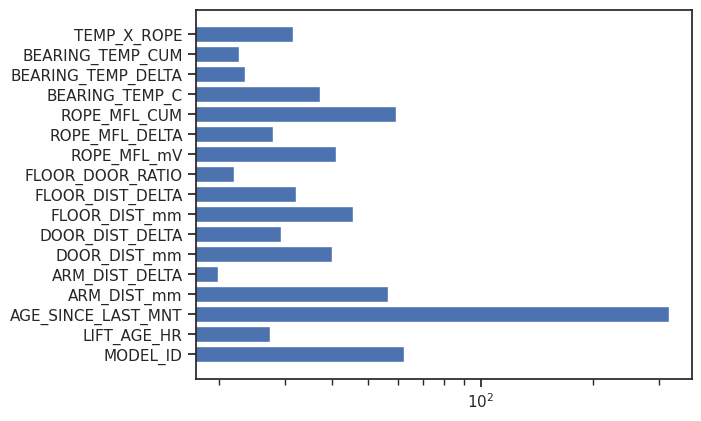

In [56]:
print("*** Getting feature importances...")
feature_importances = jiyomodel.gradient_importance(dl=test_loader)
feature_importances = dict(zip(X_cols, feature_importances))
# print(feature_importances)
f, ax = plt.subplots()
ax = plt.barh(feature_importances.keys(), feature_importances.values(), log=True)
# ax.semilogx()